###### load libraries

In [1]:
import os,shutil,numpy,pandas,geopandas,rasterio
from hsclient import HydroShare
import sys,folium
src = r'../../../../src'
sys.path.append(os.path.abspath(src))
import twtnamelist,twtmapfolium

c:\Users\GEVENSON\miniforge3\envs\nonp\Lib\site-packages\rdflib\plugin.py:111: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import iter_entry_points


In [2]:
fname_namelist = r'../../../../examples/al_appalachian_plateaus/namelist.yaml'
fname_namelist = os.path.abspath(fname_namelist)
namelist = twtnamelist.Namelist(fname_namelist)

project directory set to: u:\NonPerennialStreamPOC\examples\al_appalachian_plateaus


###### set user input

In [3]:
cuahsi_username     = 'greyevenson'
cuahsi_password     = 'Cuahsi2234'
cuashi_download_dir = os.path.abspath('./cuahsi_downloads')
#cuahsi_nm_id        = {'AIMS_SE_TAL_ENVI'           : '81c003a7b8474d63a31641a4f375fd18',
#                       'AIMS_SE_TAL_approach1_STIC' : 'ff306bec9fb24e52aa809dbb4d074731',
#                       'AIMS_SE_TAL_approach1_PRES' : '93e2861410e647d9a710eea036832dbe',
#                       'AIMS_SE_TAL_approach1_METS' : '281cd7627629481dbdc7d4ccf6fcfbcc'}
#cuahsi_nm_id        = {'AIMS_SE_WHR_ENVI'           : '126d2c7b1c8d4889a8ccc454d387b0d8',
#                       'AIMS_SE_WHR_approach1_STIC' : 'dc623510ed1847f8abe1275904472c44',
#                       'AIMS_SE_WHR_approach1_METS' : '33823d8603ce439fbba48fbcbba22da4',
#                       'AIMS_SE_WHR_approach1_PRES' : 'bc34c8b51c514bf4a6e0a44493bf8ca3'}
cuahsi_nm_id        = {'AIMS_SE_PRF_ENVI'           : '656211b1a1484433a3bc524fb968b4bd',
                       'AIMS_SE_PRF_approach1_STIC' : 'd57338ebfb0240f58e8de37ddacf9426',
                       'AIMS_SE_PRF_approach1_METS' : '4089918c0a494bfeb19be0421a33d297',
                       'AIMS_SE_PRF_approach1_PRES' : 'a45b5e24dafc4a76a665405664afada7'}

###### download data from hydroshare

In [4]:
#hydroshare = HydroShare()
#hydroshare.sign_in()
hydroshare = HydroShare(cuahsi_username, cuahsi_password)
for nm, id in cuahsi_nm_id.items():
    cuashi_download_dir = os.path.abspath(cuashi_download_dir)
    os.makedirs(cuashi_download_dir, exist_ok=True)
    nmzip = os.path.join(cuashi_download_dir, nm+'.zip')
    if not os.path.exists(nmzip):
        nmorig = hydroshare.resource(id).download(save_path=cuashi_download_dir)
        os.rename(nmorig, nmzip)
    if not os.path.isdir(os.path.join(cuashi_download_dir, nm)):
        shutil.unpack_archive(nmzip, os.path.join(os.path.dirname(nmzip), nm))

Retrieving /hsapi/resource/656211b1a1484433a3bc524fb968b4bd
Retrieving /hsapi/resource/d57338ebfb0240f58e8de37ddacf9426
Retrieving /hsapi/resource/4089918c0a494bfeb19be0421a33d297
Retrieving /hsapi/resource/a45b5e24dafc4a76a665405664afada7


##### read in-stream observations

###### get in-stream observation location and variable info

In [4]:
fname_rm_stic = ''
for root, dirs, files in os.walk(cuashi_download_dir):
    for file in files:
        if file.lower().find('.xlsx') != -1 and file.lower().find('readme') != -1 and file.lower().find('sticdata') != -1:
            fname_rm_stic = os.path.join(root,file)
if not os.path.isfile(fname_rm_stic):
    print('ERROR: could not find readme xlsx file')
dirsticlocs = os.path.dirname(fname_rm_stic)
dfsiteloc_stic = pandas.read_excel(fname_rm_stic, sheet_name='Site_Info')
gdfsiteloc_stic = geopandas.GeoDataFrame(data=dfsiteloc_stic, 
                                         geometry=geopandas.points_from_xy(dfsiteloc_stic.longitude, dfsiteloc_stic.latitude), 
                                         crs="EPSG:4326")
gdfsiteloc_stic.to_file(os.path.join(dirsticlocs,'stic_site_locations.gpkg'), driver='GPKG')
print(f'Wrote STIC site locations to: {os.path.join(dirsticlocs,"stic_site_locations.gpkg")}')
dfvarinfo_stic = pandas.read_excel(fname_rm_stic, sheet_name='Data Types')
dfvarinfo_stic = dfvarinfo_stic.dropna(subset=['Example'])
dtvarinfo_stic = dict(zip(dfvarinfo_stic['Column Name'], dfvarinfo_stic['Format']))
dtvarinfo_stic.pop('datetime') # will be parsed as datedate when reading csv
for var in dtvarinfo_stic:
    if dtvarinfo_stic[var] == 'Double':
        dtvarinfo_stic[var] = numpy.float64
    elif dtvarinfo_stic[var] == 'Integer':
        dtvarinfo_stic[var] = numpy.int64
    elif dtvarinfo_stic[var] == 'Text':
        dtvarinfo_stic[var] = numpy.str_
dtvarinfo_stic['condUncal'] = numpy.float64 # override of CUASHI metadata


Wrote STIC site locations to: u:\NonPerennialStreamPOC\examples\al_appalachian_plateaus\validation\peterson_jones_2025\cuahsi_downloads\AIMS_SE_PRF_approach1_STIC\d57338ebfb0240f58e8de37ddacf9426\data\contents\stic_site_locations.gpkg


###### get in-stream observations

In [5]:
dfobs_stic = list()
for fnm in os.listdir(os.path.dirname(fname_rm_stic)):
    if os.path.splitext(fnm)[1].lower() == '.csv':
        dfobs_stic.append(pandas.read_csv(filepath_or_buffer=os.path.join(os.path.dirname(fname_rm_stic), fnm), 
                                     parse_dates=['datetime'], #dtype=dtvarinfo_stic,parse_dates=['datetime'] 
                                     na_values=['NaN','nan']))
dfobs_stic = pandas.concat(dfobs_stic, ignore_index=True)

In [195]:
dfobs_stic.head()

,project,datetime,siteId,rType,rep,sublocation,SN,condUncal,tempC,SpC,wetdry,qual_rating,QAQC
0,AIMS,2021-09-24 22:00:00+00:00,PRA02,STIC,20210924-20220314,HS,21044184,55111.5,15.473,NaN,1.0,excellent,NaN
1,AIMS,2021-09-24 22:30:00+00:00,PRA02,STIC,20210924-20220314,HS,21044184,52355.9,15.473,NaN,1.0,excellent,NaN
2,AIMS,2021-09-24 23:00:00+00:00,PRA02,STIC,20210924-20220314,HS,21044184,52355.9,15.378,NaN,1.0,excellent,NaN
3,AIMS,2021-09-24 23:30:00+00:00,PRA02,STIC,20210924-20220314,HS,21044184,52355.9,15.282,NaN,1.0,excellent,NaN
4,AIMS,2021-09-25 00:00:00+00:00,PRA02,STIC,20210924-20220314,HS,21044184,52355.9,14.900,NaN,1.0,excellent,NaN


In [ ]:
dtperc_wet = dict()
for siteid in dfobs_stic['siteId'].unique():
    dfsite = dfobs_stic[dfobs_stic['siteId'] == siteid]
    perc_wet = 100*numpy.sum(dfsite['wetdry'] > 0.5)/dfsite.shape[0]
    dtperc_wet[(siteid)] = float(perc_wet)
df = pandas.DataFrame(list(dtperc_wet.items()), columns=['siteId', 'perc_wet'])
stic_summary_gdf = gdfsiteloc_stic.merge(df, on='siteId')

{'PRA02': 67.63474067179965, 'PRB02': 78.6580932472962, 'PRB03': 38.76385481005161, 'PRM02': 71.48076621953129, 'PRM03': 20.096349427256182, 'PRM04': 26.43148840038231, 'PRM05': 42.09112446061427, 'PRM07': 33.6555546154497, 'PRM08': 33.946044347804104, 'PRM10': 49.48543087414755, 'PRM12': 51.51840765471896, 'PRM13': 28.533783610919233, 'PRM14': 41.61308063287926, 'PRM16': 90.03934343007023, 'PRM17': 31.362338316815052, 'PRM18': 39.32650816481936, 'PRM20': 93.06467797847108, 'PRM21': 99.50616677313154, 'PRM22': 95.7609576095761, 'PRM23': 47.203222032220324}


In [208]:
stic_summary_gdf.to_file(os.path.join(dirsticlocs,'stic_site_summary_perc_wet.gpkg'), driver='GPKG')

##### read pressure transducer observations

###### get pressure transducer locations and variable info

In [6]:
fname_rm_pres = ''
for root, dirs, files in os.walk(cuashi_download_dir):
    for file in files:
        if file.lower().find('.xlsx') != -1 and file.lower().find('readme') != -1 and file.lower().find('presdata') != -1:
            fname_rm_pres = os.path.join(root,file)
if not os.path.isfile(fname_rm_pres):
    print('ERROR: could not find readme xlsx file')
dirpreslocs = os.path.dirname(fname_rm_pres)
dfsiteloc_pres = pandas.read_excel(fname_rm_pres, sheet_name='Site_Info')
gdfsiteloc_pres = geopandas.GeoDataFrame(data=dfsiteloc_pres, 
                                         geometry=geopandas.points_from_xy(dfsiteloc_pres.longitude, dfsiteloc_pres.latitude), 
                                         crs="EPSG:4326")
gdfsiteloc_pres.to_file(os.path.join(dirpreslocs,'pres_site_locations.gpkg'), driver='GPKG')
print(f'Wrote PRES site locations to: {os.path.join(dirpreslocs,"pres_site_locations.gpkg")}')
dfvarinfo_pres = pandas.read_excel(fname_rm_pres, sheet_name='Data Types')
dfvarinfo_pres = dfvarinfo_pres.dropna(subset=['Example'])
dtvarinfo_pres = dict(zip(dfvarinfo_pres['Column Name'], dfvarinfo_pres['Format']))
dtvarinfo_pres.pop('datetime') # will be parsed as datedate when reading csv
for var in dtvarinfo_pres:
    if dtvarinfo_pres[var] == 'Double':
        dtvarinfo_pres[var] = numpy.float64
    elif dtvarinfo_pres[var] == 'Integer':
        dtvarinfo_pres[var] = numpy.int64
    elif dtvarinfo_pres[var] == 'Text':
        dtvarinfo_pres[var] = numpy.str_
dtvarinfo_pres['condUncal'] = numpy.float64 # override of CUASHI metadata

Wrote PRES site locations to: u:\NonPerennialStreamPOC\examples\al_appalachian_plateaus\validation\peterson_jones_2025\cuahsi_downloads\AIMS_SE_PRF_approach1_PRES\a45b5e24dafc4a76a665405664afada7\data\contents\pres_site_locations.gpkg


###### get pressure transducer observations

In [181]:
dfobs_pres = list()
for fnm in os.listdir(os.path.dirname(fname_rm_pres)):
    if os.path.splitext(fnm)[1].lower() == '.csv':
        dfobs_pres.append(pandas.read_csv(filepath_or_buffer=os.path.join(os.path.dirname(fname_rm_pres), fnm), 
                                          dtype=dtvarinfo_pres,parse_dates=['datetime'], 
                                          na_values=['NaN','nan']))
dfobs_pres = pandas.concat(dfobs_pres, ignore_index=True)
dfobs_pres['datetime'] = pandas.to_datetime(dfobs_pres['datetime'])

###### get Peterson and Jones (2025) watershed boundary

In [8]:
fname_watershed_zip = ''
for root, dirs, files in os.walk(cuashi_download_dir):
    for file in files:
        if file.lower().find('.zip') != -1 and file.lower().find('watershed') != -1:
            fname_watershed_zip = os.path.join(root,file)
if not os.path.isfile(fname_watershed_zip):
    print('ERROR: could not find readme watershed zip file')
dirwatershed = os.path.join(os.path.dirname(fname_watershed_zip),'watershed')
shutil.unpack_archive(fname_watershed_zip, dirwatershed)
fname_watershed = os.listdir(os.path.join(os.path.dirname(fname_watershed_zip), 'watershed'))
fname_watershed = [os.path.join(os.path.dirname(fname_watershed_zip), 'watershed', f) for f in fname_watershed if os.path.splitext(f)[1].lower() == '.shp'][0]
dirwatershed = os.path.dirname(fname_watershed)
watershed = geopandas.read_file(fname_watershed).dissolve()
watershed = watershed.dissolve()
watershed['area_sqkm'] = watershed.to_crs(epsg=3395).geometry.area / 1e6
watershed.to_file(os.path.join(dirwatershed, 'watershed.gpkg'), driver='GPKG')
print(f'Wrote watershed boundary to: {os.path.join(dirwatershed,"watershed.gpkg")}')

Wrote watershed boundary to: u:\NonPerennialStreamPOC\examples\al_appalachian_plateaus\validation\peterson_jones_2025\cuahsi_downloads\AIMS_SE_PRF_ENVI\656211b1a1484433a3bc524fb968b4bd\data\contents\watershed\watershed.gpkg


In [209]:
from rasterio.mask import mask
full_fname_nonperennial = r'U:\NonPerennialStreamPOC\examples\al_appalachian_plateaus\output\060300020103\summary\nonperennial_strms_20021001_to_20060930.tiff'
full_fname_perennial = r'U:\NonPerennialStreamPOC\examples\al_appalachian_plateaus\output\060300020103\summary\perennial_strms_20021001_to_20060930.tiff'

In [ ]:
with rasterio.open(full_fname_nonperennial) as src:
    out_image, out_transform = mask(src, watershed.geometry.union_all(), crop=True, nodata=src.nodata)
    print("Raster clipped successfully.")

    # 6. Update metadata for the output file
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
        "compress": "lzw" # Optional: add compression
    })

    # 7. Write the clipped raster to a new file
    with rasterio.open(output_clipped_path, "w", **out_meta) as dest:
        dest.write(out_image)

In [9]:
domain = geopandas.read_file(os.path.join(namelist.dirnames.input, 'domain.gpkg'))
inputs_dir = os.path.join(namelist.dirnames.input,domain.iloc[0]['domain_id'])
fname_transmissivity = os.path.join(inputs_dir, 'soil_transmissivity.tiff')
fname_twi = os.path.join(inputs_dir, 'twi.tiff')
fname_twi_mean = os.path.join(inputs_dir, 'twi_mean.tiff')
fname_domain_mask = os.path.join(inputs_dir, 'domain_mask.tiff')
fname_dem = os.path.join(inputs_dir, 'dem.tiff')

###### get f values at pressure observation sites

In [183]:
with rasterio.open(fname_transmissivity,'r') as riods_f:
    f = riods_f.read(1)
    f = numpy.where(f == riods_f.nodata, numpy.nan,f)
    f_mean = numpy.nanmean(f)
    gdf_prj = gdfsiteloc_pres.to_crs(riods_f.crs)
    coords = [(gdf_prj.geometry[i].x, gdf_prj.geometry[i].y) 
             for i in range(len(gdf_prj))]
    vals   = list(riods_f.sample(coords))
    vals   = [float(v[0]) for v in vals]
    gdfsiteloc_pres['f'] = vals
for i in range(len(gdfsiteloc_pres)):
    print(f"siteId: {gdfsiteloc_pres['siteId'].values[i]}, f: {gdfsiteloc_pres['f'].values[i]:0.3f}")
dfobs_pres = pandas.merge(left=dfobs_pres, 
                          right=gdfsiteloc_pres[['siteId', 'f']].copy(), 
                          on='siteId', 
                          how='inner')

siteId: PRM01, f: 2.900
siteId: PRM06, f: 3.400
siteId: PRM09, f: 3.400
siteId: PRM11, f: 3.400
siteId: PRM15, f: 3.400
siteId: PRM19, f: 3.400
siteId: PRA01, f: 3.400
siteId: PRB01, f: 3.400


###### get twi values at pressure observation locations

In [184]:
with rasterio.open(fname_twi,'r') as riods_twi:
    twi = riods_twi.read(1)
    twi = numpy.where(twi == riods_twi.nodata, numpy.nan,twi)
    gdf_prj = gdfsiteloc_pres.to_crs(riods_twi.crs)
    coords = [(gdf_prj.geometry[i].x, gdf_prj.geometry[i].y) 
             for i in range(len(gdf_prj))]
    vals   = list(riods_twi.sample(coords))
    vals   = [float(v[0]) for v in vals]
    gdfsiteloc_pres['twi'] = vals
for i in range(len(gdfsiteloc_pres)):
    print(f"siteId: {gdfsiteloc_pres['siteId'].values[i]}, twi: {gdfsiteloc_pres['twi'].values[i]:0.3f}")
dfobs_pres = pandas.merge(left=dfobs_pres, 
                          right=gdfsiteloc_pres[['siteId', 'twi']].copy(), 
                          on='siteId', 
                          how='inner')

siteId: PRM01, twi: 6.110
siteId: PRM06, twi: 6.093
siteId: PRM09, twi: 17.007
siteId: PRM11, twi: 17.041
siteId: PRM15, twi: 7.022
siteId: PRM19, twi: 9.384
siteId: PRA01, twi: 12.995
siteId: PRB01, twi: 14.462


###### get mean twi values at pressure observation locations

In [185]:
with rasterio.open(fname_twi_mean,'r') as riods_twi_mean:
    twi_mean = riods_twi_mean.read(1)
    twi_mean = numpy.where(twi_mean == riods_twi_mean.nodata, numpy.nan,twi_mean)
    gdf_prj = gdfsiteloc_pres.to_crs(riods_twi_mean.crs)
    coords = [(gdf_prj.geometry[i].x, gdf_prj.geometry[i].y) 
             for i in range(len(gdf_prj))]
    vals   = list(riods_twi_mean.sample(coords))
    vals   = [float(v[0]) for v in vals]
    gdfsiteloc_pres['twi_mean'] = vals
for i in range(len(gdfsiteloc_pres)):
    print(f"siteId: {gdfsiteloc_pres['siteId'].values[i]}, twi mean: {gdfsiteloc_pres['twi_mean'].values[i]:0.3f}")
dfobs_pres = pandas.merge(left=dfobs_pres, 
                          right=gdfsiteloc_pres[['siteId', 'twi_mean']].copy(), 
                          on='siteId', 
                          how='inner')

siteId: PRM01, twi mean: 5.194
siteId: PRM06, twi mean: 5.381
siteId: PRM09, twi mean: 5.225
siteId: PRM11, twi mean: 5.109
siteId: PRM15, twi mean: 4.720
siteId: PRM19, twi mean: 4.831
siteId: PRA01, twi mean: 4.721
siteId: PRB01, twi mean: 5.190


###### get surface elevation at pressure observation locations

In [186]:
with rasterio.open(fname_dem,'r') as riods_dem:
    gdf_prj = gdfsiteloc_pres.to_crs(riods_dem.crs)
    coords = [(gdf_prj.geometry[i].x, gdf_prj.geometry[i].y) 
             for i in range(len(gdf_prj))]
    vals   = list(riods_dem.sample(coords))
    vals   = [float(v[0]) if v[0] != riods_dem.nodata else numpy.nan for v in vals]
    gdfsiteloc_pres['dem_elev_m'] = vals
for i in range(len(gdfsiteloc_pres)):
    print(f"siteId: {gdfsiteloc_pres['siteId'].values[i]}, dem_elev_m: {gdfsiteloc_pres['dem_elev_m'].values[i]:0.3f}")
dfobs_pres = pandas.merge(left=dfobs_pres, 
                          right=gdfsiteloc_pres[['siteId', 'dem_elev_m']].copy(), 
                          on='siteId', 
                          how='inner')

siteId: PRM01, dem_elev_m: 211.203
siteId: PRM06, dem_elev_m: 225.793
siteId: PRM09, dem_elev_m: 238.508
siteId: PRM11, dem_elev_m: 248.997
siteId: PRM15, dem_elev_m: 307.142
siteId: PRM19, dem_elev_m: 353.106
siteId: PRA01, dem_elev_m: 321.265
siteId: PRB01, dem_elev_m: 245.952


###### calculate expected mean water table depth for every pressure observation

In [187]:
dfobs_pres['waterElevation_m_fixed'] = dfobs_pres['waterElevation_m']
dfobs_pres.loc[dfobs_pres['waterElevation_m_fixed'] < -30000., 'waterElevation_m_fixed'] = numpy.nan
dfobs_pres['waterElevationBasinMean'] = dfobs_pres['waterElevation_m_fixed'] - ((dfobs_pres['twi'] - dfobs_pres['twi_mean']) / dfobs_pres['f'])

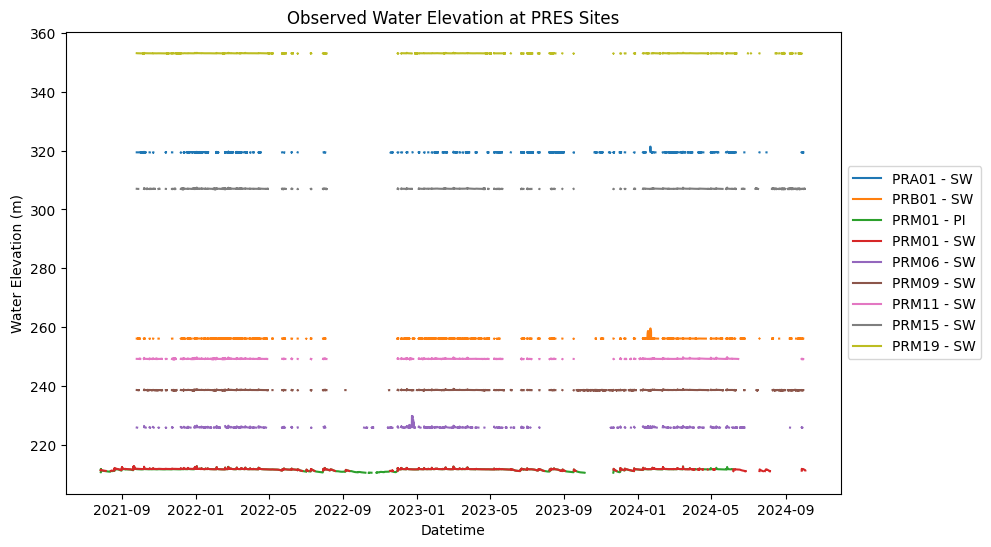

In [189]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for siteid in dfobs_pres['siteId'].unique():
    siteid_slice = dfobs_pres[dfobs_pres['siteId'] == siteid]
    for subloc in siteid_slice['sublocation'].unique():
        subloc_slice = siteid_slice[siteid_slice['sublocation'] == subloc].copy()
        plt.plot(subloc_slice['datetime'], subloc_slice['waterElevation_m_fixed'], label=f'{siteid} - {subloc}')
plt.xlabel('Datetime')
plt.ylabel('Water Elevation (m)')
plt.title('Observed Water Elevation at PRES Sites')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

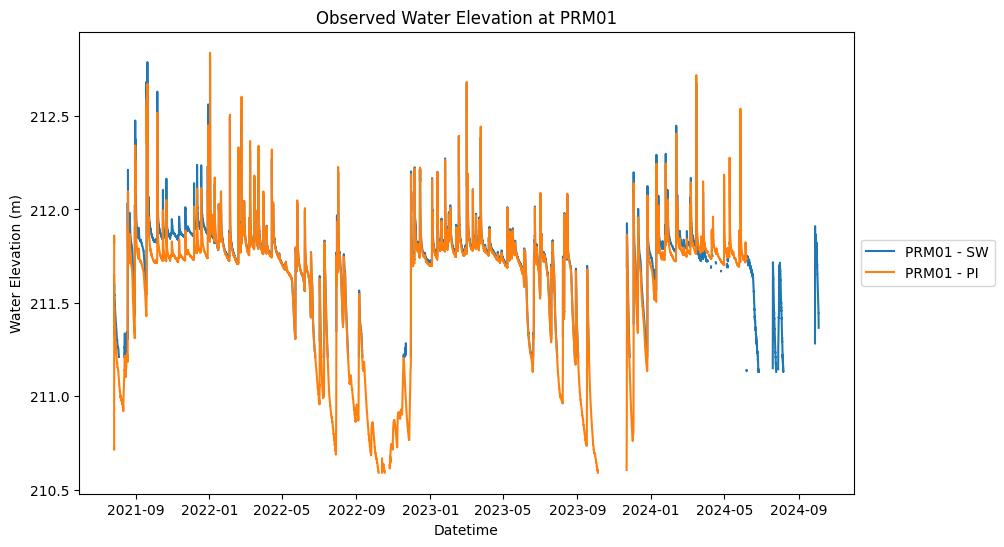

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
siteids = ['PRM01']
for siteid in dfobs_pres['siteId'].unique():
    if siteid.find("PRM01") != -1:
        siteid_slice = dfobs_pres[dfobs_pres['siteId'] == siteid]
        for subloc in siteid_slice['sublocation'].unique():
            subloc_slice = siteid_slice[siteid_slice['sublocation'] == subloc]
            plt.plot(subloc_slice['datetime'], subloc_slice['waterElevation_m_fixed'], label=f'{siteid} - {subloc}')
plt.xlabel('Datetime')
plt.ylabel('Water Elevation (m)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Observed Water Elevation at PRM01')
plt.show()


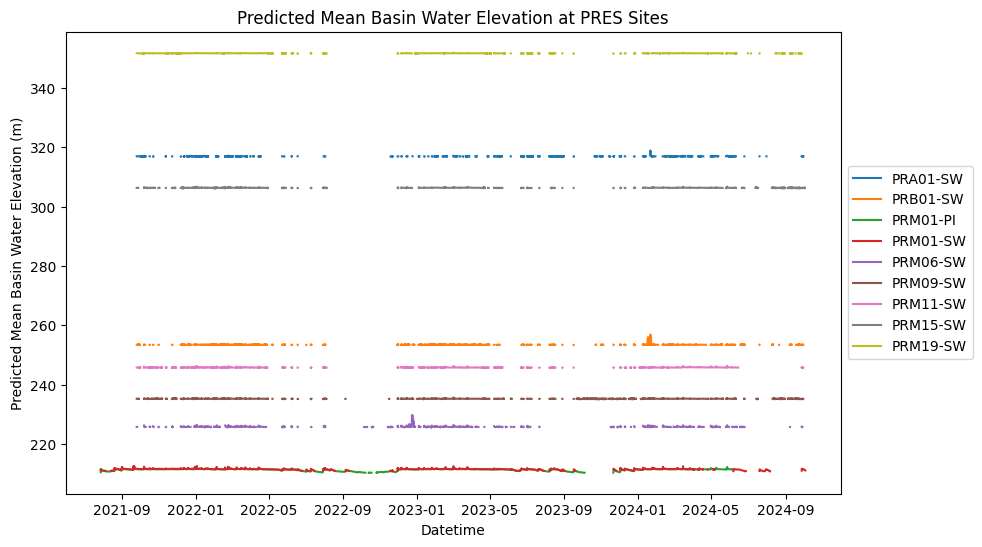

In [190]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for siteid in dfobs_pres['siteId'].unique():
    siteid_slice = dfobs_pres[dfobs_pres['siteId'] == siteid]
    for subloc in siteid_slice['sublocation'].unique():
        subloc_slice = siteid_slice[siteid_slice['sublocation'] == subloc]
        plt.plot(subloc_slice['datetime'], subloc_slice['waterElevationBasinMean'], label=f'{siteid}-{subloc}')
plt.xlabel('Datetime')
plt.ylabel('Predicted Mean Basin Water Elevation (m)')
plt.title('Predicted Mean Basin Water Elevation at PRES Sites')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

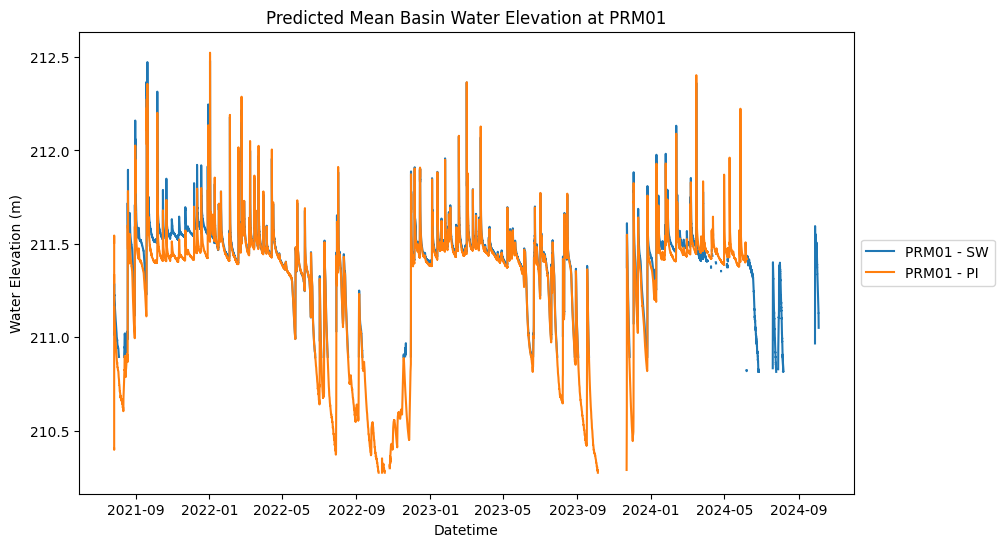

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
siteids = ['PRM01']
for siteid in dfobs_pres['siteId'].unique():
    if siteid.find("PRM01") != -1:
        siteid_slice = dfobs_pres[dfobs_pres['siteId'] == siteid]
        for subloc in siteid_slice['sublocation'].unique():
            subloc_slice = siteid_slice[siteid_slice['sublocation'] == subloc]
            plt.plot(subloc_slice['datetime'], subloc_slice['waterElevationBasinMean'], label=f'{siteid} - {subloc}')
plt.xlabel('Datetime')
plt.ylabel('Water Elevation (m)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Predicted Mean Basin Water Elevation at PRM01')
plt.show()

###### predict surface wetness for whole of domain for each time step. this will take a while so use a progress bar

In [ ]:
dirout      = os.path.abspath(os.path.join(cuashi_download_dir, 'output'))
os.makedirs(dirout, exist_ok=True)
print(f'writing basin scale wetness predictions to: {dirout}')
twi_local   = rasterio.open(fname_twi,'r').read(1)
trans_decay = rasterio.open(fname_transmissivity,'r').read(1)
domain_mask = rasterio.open(fname_domain_mask,'r').read(1)
domain_total = numpy.nansum(domain_mask)
dst_meta    = rasterio.open(fname_dem,'r').meta.copy()
from tqdm.notebook import tqdm
for i in tqdm(range(len(waterLevelPredictedBasinMean_m))):
    wtd_m = waterLevelPredictedBasinMean_m.iloc[i]['mean_waterLevelPredictedBasinMean_m']
    wtd_l = numpy.where(domain_mask==1, (twi_local - twi_mean + trans_decay * wtd_m) / trans_decay, numpy.nan)
    wet_l = numpy.where((wtd_l >= 0) & (domain_mask==1),1,0).astype(numpy.uint8)
    bsn_pct_wet = (numpy.sum(wet_l) / domain_total) * 100.0
    dst_meta    = rasterio.open(fname_dem,'r').meta.copy()
    dst_meta.update({'dtype'  : rasterio.uint8,
                     'nodata' : 0})
    fname_out = os.path.join(dirout,f'wet{waterLevelPredictedBasinMean_m.iloc[i]['datetime'].strftime("%Y%m%d%H%M%S")}.tiff')
    with rasterio.open(fname_out,'w',**dst_meta) as riods_out:
        riods_out.write(wet_l,1)
        riods_out.update_tags(bsn_pct_wet=bsn_pct_wet) # add basin percent wet as tag in the output file


printing wet predictions to: u:\peterson_jones_2025\data\AIMS_SE_TAL\output


  0%|          | 0/110285 [00:00<?, ?it/s]

###### calculate

In [59]:
dirout = os.path.join(cuashi_download_dir, 'output')
mask = rasterio.open(fname_domain_mask, 'r').read(1)
bsn_tot = numpy.nansum(numpy.where(mask == 1, 1, numpy.nan))
from tqdm.notebook import tqdm
for i in tqdm(range(len(waterLevelPredictedBasinMean_m))):
    fname_output_i = os.path.join(dirout, f'wet{waterLevelPredictedBasinMean_m.iloc[i]["datetime"].strftime("%Y%m%d%H%M%S")}.tiff')
    with rasterio.open(fname_output_i, 'r+') as riods_i:  # Open in read-write mode to allow updates
        bsn_pct_wet = float(riods_i.tags().get('bsn_pct_wet', numpy.nan))
        if numpy.isnan(bsn_pct_wet):
            wet_tot = numpy.nansum(numpy.where(riods_i.read(1) == 1, 1, numpy.nan)) # this is probably converting grid to float internally due to nan presence. faster to sum whole grid even outside mask?
            bsn_pct_wet = (wet_tot / bsn_tot)*100.0
            riods_i.update_tags(bsn_pct_wet=bsn_pct_wet)  # Add bsn_pct_wet as a custom tag to the file's metadata

  0%|          | 0/110285 [00:00<?, ?it/s]

In [60]:
datetimes,bsn_pct_wets = list(),list()
for i in tqdm(range(len(waterLevelPredictedBasinMean_m))):
    fname_output_i = os.path.join(dirout, f'wet{waterLevelPredictedBasinMean_m.iloc[i]["datetime"].strftime("%Y%m%d%H%M%S")}.tiff')
    with rasterio.open(fname_output_i, 'r+') as riods_i:  # Open in read-write mode to allow updates
        bsn_pct_wet = float(riods_i.tags().get('bsn_pct_wet', numpy.nan))
        if ~numpy.isnan(bsn_pct_wet):
            datetimes.append(waterLevelPredictedBasinMean_m.iloc[i]["datetime"])
            bsn_pct_wets.append(bsn_pct_wet)
bsn_pct_wet = pandas.DataFrame({'datetime': datetimes, 'bsn_pct_wet': bsn_pct_wets})

  0%|          | 0/110285 [00:00<?, ?it/s]

In [63]:
bsn_pct_wet['bsn_pct_wet'].describe()

count    110285.000000
mean          0.232352
std           0.105660
min           0.000000
25%           0.234597
50%           0.247738
75%           0.273843
max           0.732013
Name: bsn_pct_wet, dtype: float64

###### make gif from predicted wetness tiff time series

In [61]:
datetime_min = ''
datetime_max = ''
import imageio
fnames = [os.path.join(dirout,f'wet{waterLevelPredictedBasinMean_m.iloc[i]['datetime'].strftime("%Y%m%d%H%M%S")}.tiff') for i in range(len(waterLevelPredictedBasinMean_m))
		  if waterLevelPredictedBasinMean_m.iloc[i]['datetime'] ]
with imageio.get_writer('./output.gif', mode='I', fps=2, loop=0) as writer:
	for fname in fnames:
		image = imageio.imread(fname)
		writer.append_data(image)

C:\Users\GEVENSON\AppData\Local\Temp\ipykernel_52652\1655899724.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(fname)


KeyboardInterrupt: 

In [ ]:
from IPython.display import Image, display
with open('./output.gif', 'rb') as f:
    display(Image(data=f.read(), format='gif'))

In [ ]:
fnames

In [64]:
vs_siteIds, vs_wet, vs_datetime = list(), list(), list()
gdf_prj = gdfsiteloc_stic.to_crs(rasterio.open(fname_dem,'r').meta['crs'])[['siteId','geometry']]
site_coords = [(gdf_prj.geometry[i].x, gdf_prj.geometry[i].y) for i in range(len(gdf_prj))]
for dt in dfobs_stic['datetime'].unique():
    fname_out = os.path.join(dirout,f'wet{dt.strftime("%Y%m%d%H%M%S")}.tiff')
    if os.path.isfile(fname_out):
        with rasterio.open(fname_out,'r') as riods_wet:
            wet = riods_wet.read(1)
            wet = numpy.where(wet == riods_wet.meta['nodata'], numpy.nan, wet)
            vals   = list(riods_wet.sample(site_coords))
            vs_siteIds.extend(gdf_prj['siteId'].values)
            vs_wet.extend([int(v[0]) for v in vals])
            vs_datetime.extend([dt for _ in range(len(gdf_prj))])
results = pandas.DataFrame({
    'siteId'  : vs_siteIds,
    'wet'     : vs_wet,
    'datetime': vs_datetime
})

###### join predicted/simulated wetness to observed wetness on siteId and datetime columns

In [65]:
results.rename(columns={'wet': 'wetdry_predict'}, inplace=True)
results = pandas.merge(dfobs_stic[['siteId', 'datetime', 'wetdry']], results, on=['siteId', 'datetime'], how='inner')
match_count = (results['wetdry'] == results['wetdry_predict'].astype(int)).sum()

In [66]:
for siteId in gdfsiteloc_stic['siteId'].unique():
    site_data = results[results['siteId'] == siteId]
    observed_wet_count = site_data['wetdry'].sum()
    predicted_wet_count = site_data['wetdry_predict'].sum()
    total     = len(site_data)
    correct   = (site_data['wetdry'] == site_data['wetdry_predict'].astype(int)).sum()
    print(f'siteId: {siteId}, observed wet: {observed_wet_count}/{total} = {observed_wet_count/total:0.3f}, predicted wet: {predicted_wet_count}/{total} = {predicted_wet_count/total:0.3f}, accuracy: {correct}/{total} = {correct/total:0.3f}')

siteId: TLA02, observed wet: 86789/92083 = 0.943, predicted wet: 86023/92083 = 0.934, accuracy: 83541/92083 = 0.907
siteId: TLA03, observed wet: 92083/92083 = 1.000, predicted wet: 86938/92083 = 0.944, accuracy: 86938/92083 = 0.944
siteId: TLA04, observed wet: 86560/92083 = 0.940, predicted wet: 0/92083 = 0.000, accuracy: 5523/92083 = 0.060
siteId: TLA05, observed wet: 2069/32012 = 0.065, predicted wet: 0/32012 = 0.000, accuracy: 29943/32012 = 0.935
siteId: TLA06, observed wet: 3126/32012 = 0.098, predicted wet: 0/32012 = 0.000, accuracy: 28886/32012 = 0.902
siteId: TLA07, observed wet: 32012/32012 = 1.000, predicted wet: 0/32012 = 0.000, accuracy: 0/32012 = 0.000
siteId: TLA08, observed wet: 669/32012 = 0.021, predicted wet: 0/32012 = 0.000, accuracy: 31343/32012 = 0.979
siteId: TLAG4, observed wet: 32012/32012 = 1.000, predicted wet: 0/32012 = 0.000, accuracy: 0/32012 = 0.000
siteId: TLB01, observed wet: 69240/92079 = 0.752, predicted wet: 0/92079 = 0.000, accuracy: 22839/92079 = 0.2